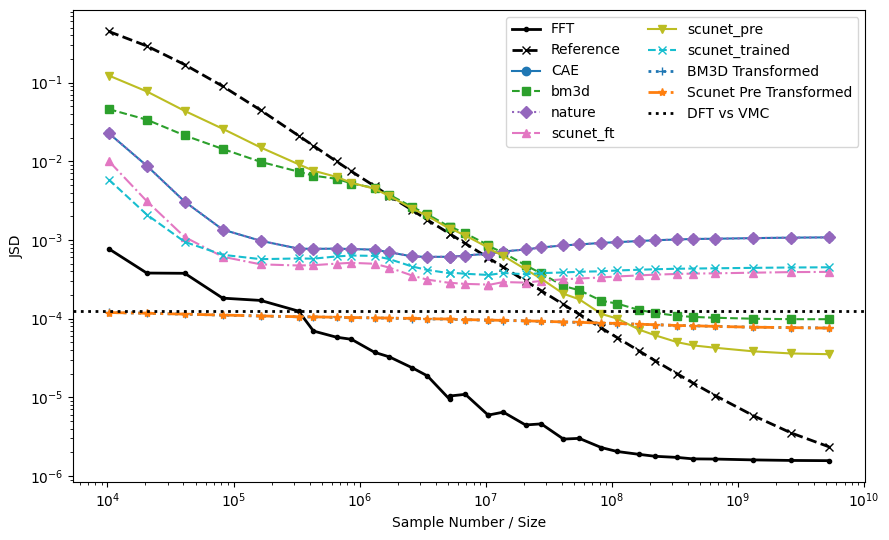

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import logging

filename = "plot_img_data.h5"

with h5py.File(filename, "r") as hf:
    model_results_FFT = hf["FFT"][()]
    results_array_ref = hf["Reference"][()]
    DFT_vs_VMC = hf["DFT_vs_VMC"][()]
    
    results_dict = {name: hf["ML_Models"][name][()] for name in hf["ML_Models"]}
    loaded_data = {name: hf["Transformed_Methods"][name][()] for name in hf["Transformed_Methods"]}

    models = list(results_dict.keys())

logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(9, 5.5))

markers = ["o", "s", "D", "^", "v", "x", "+", "*", "P", "<", ">"]
linestyles = ["-", "--", ":", "-."]
marker_idx = 0
line_idx = 0

# FFT
x_fft, y_fft = zip(*model_results_FFT)
plt.loglog(x_fft, y_fft, marker=".", linestyle="-", color="black", linewidth=2, label="FFT")

# Reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1], marker="x", 
           linestyle="--", color="black", linewidth=2, label="Reference")

# Main ML models
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]
    results_array = results_array[np.argsort(results_array[:, 0])]
    
    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        color=color,
        label=model_name,
    )
    marker_idx += 1
    line_idx += 1

# Transformed methods
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])
    label = "Scunet Pre Transformed" if method == "scunet_pre" else "BM3D Transformed"

    plt.loglog(
        x, y,
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        linewidth=2,
        label=label,
    )
    marker_idx += 1
    line_idx += 1

# DFT vs VMC line
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", linewidth=2, label="DFT vs VMC")

# Decorations
plt.xlabel("Sample Number / Size")
plt.ylabel("JSD")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
